In [11]:

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from scipy.linalg import eigh
from numpy import pi, exp, sqrt, real, imag

# ================================== 基本设置 ==================================
N = 2**3
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
dx = 2*pi/N

def kinetic_operator(n, dt):
    qc = QuantumCircuit(n)
    qc.rz(-2**(n-1)*dt, n-1)
    for i in range(n):
        qc.rz(2**(n-i-2)*dt, n-i-1)
    for i in range(1, n):
        qc.cx(n-1, n-i-1)
        qc.rz(-2**(2*n-i-2)*dt, n-i-1)
        qc.cx(n-1, n-i-1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n-i-1, n-j-1)
                qc.rz(2**(2*n-i-j-4)*dt, n-j-1)
                qc.cx(n-i-1, n-j-1)
    return qc

def evolve(nx, ny, dt, initial_state):
    q_num = nx + ny + 1
    circ = QuantumCircuit(q_num)
    circ.initialize(initial_state)
    circ.barrier()

    from qiskit.circuit.library import QFT
    QFT_x = QFT(nx)
    QFT_y = QFT(ny)
    IQFT_x = QFT(nx).inverse()
    IQFT_y = QFT(ny).inverse()

    kinetic_x = kinetic_operator(nx, dt)
    kinetic_y = kinetic_operator(ny, dt)

    circ.append(QFT_x, range(nx))
    circ.append(QFT_y, range(nx, nx+ny))
    circ.barrier()
    circ.append(kinetic_x, range(nx))
    circ.append(kinetic_y, range(nx, nx+ny))
    circ.barrier()
    circ.append(IQFT_x, range(nx))
    circ.append(IQFT_y, range(nx, nx+ny))
    circ.save_statevector()

    simulator = AerSimulator(method='statevector')
    circ = transpile(circ, simulator)
    result = simulator.run(circ).result()
    return np.array(result.data(0)['statevector'])

# ================================== 初始条件 ==================================
x0, y0 = 0, 0
R = np.sqrt((X - x0)**2 + (Y - y0)**2)
sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)
initial_state = np.array([psi1_0, psi2_0]).reshape(-1)
initial_state = initial_state / np.linalg.norm(initial_state)

# ================================== Shadow 验证模块 ==================================
def get_density_operators(nx, ny, points):
    def index(ix, iy): return iy * (2**nx) + ix
    obs = []
    for (ix, iy) in points:
        idx = index(ix, iy)
        O = np.zeros((2*N*N, 2*N*N), dtype=complex)
        O[idx, idx] = 1.0
        O[idx+N*N, idx+N*N] = 1.0
        obs.append(O)
    return obs

def get_expectation(statevec, observables):
    return [np.real(statevec.conj().T @ (O @ statevec)) for O in observables]

def build_shadow_evolution_circuit(H_S, init_expvals, t):
    M = len(init_expvals)
    psi0 = np.array(init_expvals, dtype=complex)
    psi0 /= np.linalg.norm(psi0)
    n_shadow = int(np.ceil(np.log2(M)))
    dim = 2**n_shadow

    init_state = np.zeros(dim, dtype=complex)
    init_state[:M] = psi0

    eigvals, V = eigh(H_S)
    U_s = V @ np.diag(np.exp(-1j * eigvals * t)) @ V.conj().T
    U_pad = np.eye(dim, dtype=complex)
    U_pad[:M, :M] = U_s

    circ = QuantumCircuit(n_shadow)
    circ.initialize(init_state, range(n_shadow))
    circ.append(Operator(U_pad), range(n_shadow))
    circ.save_statevector()
    return circ, n_shadow

from qiskit.circuit.library import QFT

def construct_kinetic_H_phys(N):
    """
    构造二维动能算符在位置空间（x-y）的表示：
    H_phys = (QFT† ⊗ QFT†) · diag(-k²) · (QFT ⊗ QFT)

    返回:
        H_phys: ndarray, (2N², 2N²) 的复数矩阵（双分量结构）
    """
    k = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(k, k)
    Lap = -(KX**2 + KY**2)
    T = np.diag(Lap.flatten())

    from qiskit.quantum_info import Operator
    qft_circ = QFT(int(np.log2(N)), do_swaps=False)
    qft = Operator(qft_circ).data

    qft2d = np.kron(qft, qft)
    iqft2d = qft2d.conj().T

    T_pos = iqft2d @ T @ qft2d

    H_phys = np.zeros((2*N*N, 2*N*N), dtype=complex)
    H_phys[:N*N, :N*N] = T_pos
    H_phys[N*N:, N*N:] = T_pos
    return H_phys


def construct_shadow_HS_commutator(H_phys, observables):
    M = len(observables)
    D = H_phys.shape[0]
    H_S = np.zeros((M, M), dtype=complex)
    for m, Om in enumerate(observables):
        comm = H_phys @ Om - Om @ H_phys
        for n, On in enumerate(observables):
            H_S[m, n] = 1j * np.trace(On.conj().T @ comm) / D
    H_S = (H_S + H_S.conj().T) / 2
    return H_S

def add_perturbation_to_observables(observables, eps=1e-3, seed=42):
    """
    在每个观测算符 O_m 上加一个小扰动项 R_m，使其与 H 不再对易。
    返回扰动后的 observable 列表。
    """
    np.random.seed(seed)
    perturbed_obs = []
    dim = observables[0].shape[0]
    for O in observables:
        # 构造随机扰动：Hermitian 矩阵 R = A + A†
        A = (np.random.rand(dim, dim) + 1j * np.random.rand(dim, dim)) - 0.5
        R = A + A.conj().T
        O_tilde = O + eps * R
        perturbed_obs.append(O_tilde)
    return perturbed_obs

def get_density_operators_with_perturbation(nx, ny, points, eps=1e-3, seed=42):
    """
    构造观测量 O_i = |i⟩⟨i|_1 + |i⟩⟨i|_2 + ε * Δ_i
    其中 Δ_i 是非对易扰动项，例如稀疏非厄米矩阵

    参数:
        nx, ny: 网格维度（2^nx × 2^ny）
        points: 观测的网格坐标 [(ix, iy), ...]
        eps: 扰动幅度，默认 1e-3
        seed: 随机种子控制可复现性
    返回:
        observables: List of (2N² × 2N²) ndarray Hermitian 观测矩阵
    """
    np.random.seed(seed)
    def index(ix, iy): return iy * (2**nx) + ix
    obs = []
    D = 2 * (2**nx) * (2**ny)

    for (ix, iy) in points:
        idx = index(ix, iy)
        O = np.zeros((D, D), dtype=complex)
        O[idx, idx] = 1.0
        O[idx + D//2, idx + D//2] = 1.0  # 对应双分量

        # 添加非对易扰动：一个稀疏随机矩阵 + 其厄米共轭
        delta = np.zeros((D, D), dtype=complex)
        rand_idx = np.random.choice(D, size=4, replace=False)
        for j in rand_idx:
            if j != idx:
                delta[idx, j] = np.random.rand() + 1j*np.random.rand()
        delta = delta + delta.conj().T  # 保证厄米性
        O += eps * delta

        obs.append(O)
    return obs


In [12]:
# ========== 参数与观测点 ==========
nx = ny = 3
#dt = 10.0
dt = np.pi
all_points = [(ix, iy) for ix in range(N) for iy in range(N)]
observables = get_density_operators(nx, ny, all_points)
#observables = get_density_operators_with_perturbation(nx, ny, all_points, eps=1e-3)

# ========== 构造 H_S ==========
state_0 = evolve(nx, ny, 0.0, initial_state)
H_phys = construct_kinetic_H_phys(N)
H_S = construct_shadow_HS_commutator(H_phys, observables)
#observables_perturbed = add_perturbation_to_observables(observables, eps=1e-3)
#H_S = construct_shadow_HS_commutator(H_phys, observables_perturbed)

print("H_S norm =", np.linalg.norm(H_S))
print("H_S (submatrix):\n", H_S[:5, :5])


H_S norm = 0.0
H_S (submatrix):
 [[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [13]:
# ========== 演化并对比 ==========
init_expect = get_expectation(state_0, observables)
shadow_circ, n_shadow = build_shadow_evolution_circuit(H_S, init_expect, t=dt)
sim = AerSimulator(method='statevector')
shadow_circ = transpile(shadow_circ, sim)
result = sim.run(shadow_circ).result()
statevec_shadow = np.array(Statevector(result.data(0)['statevector']))
shadow_expect = np.real(statevec_shadow[:len(observables)]) * np.linalg.norm(init_expect)

state_1 = evolve(nx, ny, dt, initial_state)
full_expect = get_expectation(state_1, observables)

print(f"\n✅ Shadow Hamiltonian Simulation 验证 (t = {dt}):")
for i, pt in enumerate(all_points):
    epsilon = 1e-12
    err = abs(full_expect[i] - shadow_expect[i]) / (abs(full_expect[i]) + epsilon)
    print(f"  网格点 {pt}:  全态 = {full_expect[i]:.6f},  影子 = {shadow_expect[i]:.6f},  相对误差 = {err:.2e}")
    


✅ Shadow Hamiltonian Simulation 验证 (t = 3.141592653589793):
  网格点 (0, 0):  全态 = 0.015340,  影子 = 0.015625,  相对误差 = 1.86e-02
  网格点 (0, 1):  全态 = 0.022313,  影子 = 0.015625,  相对误差 = 3.00e-01
  网格点 (0, 2):  全态 = 0.015669,  影子 = 0.015625,  相对误差 = 2.81e-03
  网格点 (0, 3):  全态 = 0.008986,  影子 = 0.015625,  相对误差 = 7.39e-01
  网格点 (0, 4):  全态 = 0.015903,  影子 = 0.015625,  相对误差 = 1.75e-02
  网格点 (0, 5):  全态 = 0.011115,  影子 = 0.015625,  相对误差 = 4.06e-01
  网格点 (0, 6):  全态 = 0.015581,  影子 = 0.015625,  相对误差 = 2.83e-03
  网格点 (0, 7):  全态 = 0.020086,  影子 = 0.015625,  相对误差 = 2.22e-01
  网格点 (1, 0):  全态 = 0.020086,  影子 = 0.015625,  相对误差 = 2.22e-01
  网格点 (1, 1):  全态 = 0.020726,  影子 = 0.015625,  相对误差 = 2.46e-01
  网格点 (1, 2):  全态 = 0.011090,  影子 = 0.015625,  相对误差 = 4.09e-01
  网格点 (1, 3):  全态 = 0.003990,  影子 = 0.015625,  相对误差 = 2.92e+00
  网格点 (1, 4):  全态 = 0.011115,  影子 = 0.015625,  相对误差 = 4.06e-01
  网格点 (1, 5):  全态 = 0.017058,  影子 = 0.015625,  相对误差 = 8.40e-02
  网格点 (1, 6):  全态 = 0.020160,  影子 = 0.015625,  相对误差 = 2.2

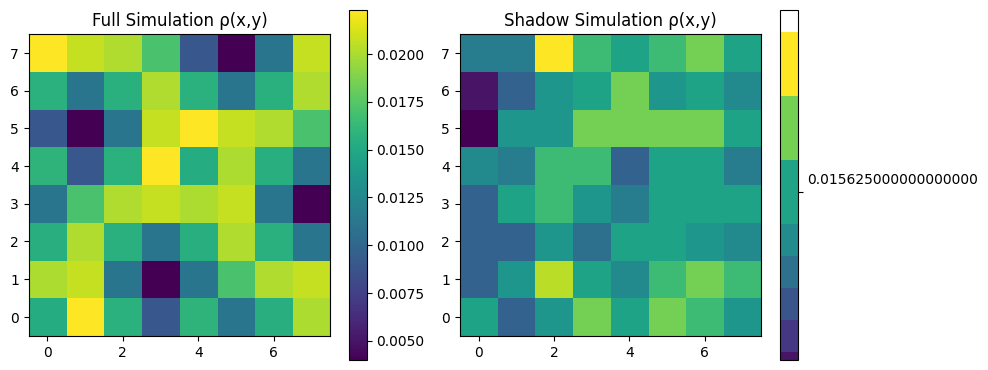

In [14]:
# 全态演化结果
state_1 = evolve(nx, ny, dt, initial_state)
full_rho = get_expectation(state_1, observables)
full_rho_map = np.array(full_rho).reshape(N, N)

# 影子态重建
shadow_expect = np.real(statevec_shadow[:N*N]) * np.linalg.norm(init_expect)
shadow_rho_map = np.array(shadow_expect).reshape(N, N)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im0 = axs[0].imshow(full_rho_map, origin='lower', cmap='viridis')
axs[0].set_title("Full Simulation ρ(x,y)")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(shadow_rho_map, origin='lower', cmap='viridis')
axs[1].set_title("Shadow Simulation ρ(x,y)")
plt.colorbar(im1, ax=axs[1])
plt.tight_layout()
plt.show()
